#📌 Extracción

In [28]:
# Importaciones globales (ejecutar una sola vez al inicio)
try:
    import pandas as pd
except ModuleNotFoundError:
    %pip install pandas
    import pandas as pd

try:
    import numpy as np
except ModuleNotFoundError:
    %pip install numpy
    import numpy as np

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    %pip install matplotlib
    import matplotlib.pyplot as plt

from pathlib import Path

# Carga de datos
ruta_json = Path("TelecomX_Data.json")

if not ruta_json.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {ruta_json.resolve()}")

df_telecom = pd.read_json(ruta_json)

print(f"Registros cargados: {df_telecom.shape[0]}")
print(f"Columnas cargadas: {df_telecom.shape[1]}")

display(df_telecom.head())
df_telecom.dtypes

Registros cargados: 7267
Columnas cargadas: 6


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


customerID       str
Churn            str
customer      object
phone         object
internet      object
account       object
dtype: object

#🔧 Transformación

In [29]:
# 1) Estructura general del dataset extraído
display(pd.DataFrame({
    "columna": df_telecom.columns,
    "dtype": df_telecom.dtypes.astype(str).values
}))

print("\nResumen con info():")
df_telecom.info()

print("\nValores nulos por columna:")
display(df_telecom.isna().sum().to_frame("nulos"))

# 2) Consulta del diccionario de datos
ruta_diccionario = Path("TelecomX_diccionario.md")
if ruta_diccionario.exists():
    print("\nDiccionario de datos (extracto):")
    print(ruta_diccionario.read_text(encoding="utf-8"))
else:
    print("\nNo se encontró TelecomX_diccionario.md")

# 3) Identificación de variables relevantes para churn
# Aplanamos temporalmente para mapear variables del diccionario
df_flat = pd.json_normalize(df_telecom.to_dict(orient="records"), sep=".")

relevantes_churn = [
    "Churn",                  # variable objetivo
    "customer.gender",
    "customer.SeniorCitizen",
    "customer.Partner",
    "customer.Dependents",
    "customer.tenure",
    "phone.PhoneService",
    "phone.MultipleLines",
    "internet.InternetService",
    "internet.OnlineSecurity",
    "internet.OnlineBackup",
    "internet.DeviceProtection",
    "internet.TechSupport",
    "internet.StreamingTV",
    "internet.StreamingMovies",
    "account.Contract",
    "account.PaperlessBilling",
    "account.PaymentMethod",
    "account.Charges.Monthly",
    "account.Charges.Total",
]

relevantes_disponibles = [col for col in relevantes_churn if col in df_flat.columns]

print("\nColumnas relevantes disponibles para análisis de evasión:")
for col in relevantes_disponibles:
    print(f"- {col}")

print(f"\nTotal relevantes encontradas: {len(relevantes_disponibles)} de {len(relevantes_churn)}")

display(df_flat[relevantes_disponibles].head())

,columna,dtype
0,customerID,str
1,Churn,str
2,customer,object
3,phone,object
4,internet,object
5,account,object



Resumen con info():
<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   str   
 1   Churn       7267 non-null   str   
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(4), str(2)
memory usage: 340.8+ KB

Valores nulos por columna:


,nulos
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0



Diccionario de datos (extracto):
#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de stre

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#📊 Carga y análisis

## Flujo de trabajo de esta sección
En esta parte se sigue el siguiente orden:
1. Comprobar incoherencias en el dataset original aplanado.
2. Aplicar limpieza y tratamiento para construir `df_limpio`.
3. Crear variables derivadas (como `Cuentas_Diarias`).
4. Realizar análisis descriptivo y visual por tipo de variable.

In [30]:
# Comprobación de incoherencias en los datos

# Usamos el dataset aplanado generado en la sección anterior (df_flat)
if "df_flat" not in globals():
    df_flat = pd.json_normalize(df_telecom.to_dict(orient="records"), sep=".")

print(f"Registros: {df_flat.shape[0]} | Columnas: {df_flat.shape[1]}")

# 1) Valores ausentes y vacíos en texto
nulos = df_flat.isna().sum().sort_values(ascending=False)
nulos = nulos[nulos > 0]

columnas_texto = df_flat.select_dtypes(include=["object", "string"]).columns
vacios_texto = pd.Series({
    col: df_flat[col].astype(str).str.strip().eq("").sum() for col in columnas_texto
})
vacios_texto = vacios_texto[vacios_texto > 0].sort_values(ascending=False)

print("\n1) Valores ausentes y vacíos")
if nulos.empty and vacios_texto.empty:
    print("No se detectaron nulos ni cadenas vacías.")
else:
    if not nulos.empty:
        resumen_nulos = pd.DataFrame({
            "nulos": nulos,
            "%": (nulos / len(df_flat) * 100).round(2)
        })
        print("Nulos por columna:")
        display(resumen_nulos)
    if not vacios_texto.empty:
        resumen_vacios = pd.DataFrame({
            "cadenas_vacias": vacios_texto,
            "%": (vacios_texto / len(df_flat) * 100).round(2)
        })
        print("Cadenas vacías por columna de texto:")
        display(resumen_vacios)

# 2) Duplicados (fila completa y por id de cliente)
print("\n2) Duplicados")
duplicados_fila = df_flat.duplicated().sum()
print(f"Filas completamente duplicadas: {duplicados_fila}")

if "customerID" in df_flat.columns:
    dup_customer = df_flat["customerID"].duplicated().sum()
    print(f"customerID duplicados: {dup_customer}")
    if dup_customer > 0:
        display(df_flat[df_flat["customerID"].duplicated(keep=False)].sort_values("customerID").head(10))
else:
    print("No existe la columna customerID para validar duplicados por cliente.")

# 3) Errores de formato y consistencia básica
print("\n3) Formato y consistencia")

# 3.1 account.Charges.Total debería ser numérico
if "account.Charges.Total" in df_flat.columns:
    total_original = df_flat["account.Charges.Total"]
    total_num = pd.to_numeric(total_original, errors="coerce")
    mascara_invalida = total_original.notna() & total_original.astype(str).str.strip().ne("") & total_num.isna()
    invalidos_total = mascara_invalida.sum()
    print(f"Valores no numéricos en account.Charges.Total (excluye vacíos): {invalidos_total}")
    if invalidos_total > 0:
        display(df_flat.loc[mascara_invalida, ["customerID", "account.Charges.Total"]].head(10))

# 3.2 tenure no debería ser negativo
if "customer.tenure" in df_flat.columns:
    tenure_num = pd.to_numeric(df_flat["customer.tenure"], errors="coerce")
    tenure_neg = (tenure_num < 0).sum()
    tenure_inval = tenure_num.isna().sum()
    print(f"Tenure negativo: {tenure_neg} | Tenure no numérico/nulo: {tenure_inval}")

# 4) Inconsistencias en categorías (espacios, mayúsculas/minúsculas)
print("\n4) Inconsistencias en categorías")
columnas_categoricas = df_flat.select_dtypes(include=["object", "string"]).columns.tolist()

# Excluimos ids/campos libres para enfocarnos en categorías
excluir = {"customerID"}
columnas_categoricas = [c for c in columnas_categoricas if c not in excluir]

inconsistencias = []
for col in columnas_categoricas:
    serie = df_flat[col].dropna().astype(str)
    serie = serie[serie.str.strip().ne("")]
    if serie.empty:
        continue
    normalizada = serie.str.strip().str.lower()
    mapeo = pd.DataFrame({"original": serie, "normalizada": normalizada})
    variantes = mapeo.groupby("normalizada")["original"].nunique()
    if (variantes > 1).any():
        ejemplos = (
            mapeo.groupby("normalizada")["original"]
            .unique()
            .loc[variantes[variantes > 1].index]
            .head(5)
        )
        inconsistencias.append((col, ejemplos))

if not inconsistencias:
    print("No se detectaron inconsistencias de escritura en categorías (trim/lower).")
else:
    print(f"Columnas con posibles inconsistencias de categorías: {len(inconsistencias)}")
    for col, ejemplos in inconsistencias:
        print(f"\n- {col}")
        for base, vars_ in ejemplos.items():
            print(f"  '{base}' -> {list(vars_)}")

# 5) Resumen de categorías con pandas.unique()
print("\n5) Categorías únicas (muestra)")
for col in [
    "Churn", "customer.gender", "customer.Partner", "customer.Dependents",
    "internet.InternetService", "account.Contract", "account.PaymentMethod"
]:
    if col in df_flat.columns:
        unicos = pd.unique(df_flat[col].dropna())
        print(f"{col}: {unicos[:10]}{' ...' if len(unicos) > 10 else ''}")

# 6) Fechas: normalización con dt.normalize() (si existen columnas datetime)
print("\n6) Verificación de fechas (dt.normalize)")
columnas_datetime = df_flat.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()

if not columnas_datetime:
    print("No hay columnas datetime ya tipadas en el dataset.")
else:
    for col in columnas_datetime:
        fechas_norm = df_flat[col].dt.normalize()
        print(f"{col}: días únicos = {fechas_norm.nunique()}")

print("\nComprobación finalizada.")

Registros: 7267 | Columnas: 21

1) Valores ausentes y vacíos
Cadenas vacías por columna de texto:


,cadenas_vacias,%
Churn,224,3.08
account.Charges.Total,11,0.15



2) Duplicados
Filas completamente duplicadas: 0
customerID duplicados: 0

3) Formato y consistencia
Valores no numéricos en account.Charges.Total (excluye vacíos): 0
Tenure negativo: 0 | Tenure no numérico/nulo: 0

4) Inconsistencias en categorías
No se detectaron inconsistencias de escritura en categorías (trim/lower).

5) Categorías únicas (muestra)
Churn: <StringArray>
['No', 'Yes', '']
Length: 3, dtype: str
customer.gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
customer.Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
customer.Dependents: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
internet.InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
account.Contract: <StringArray>
['One year', 'Month-to-month', 'Two year']
Length: 3, dtype: str
account.PaymentMethod: <StringArray>
[             'Mailed check',          'Electronic check',
   'Credit card (automatic)', 'Bank transfer (automatic)']
Length: 4, dtype: str

6) Veri

In [31]:
# Manejo de inconsistencias

# Partimos del dataset aplanado
df_limpio = df_flat.copy()

# 1) Limpieza de strings: trim + minúsculas controladas + espacios consistentes
columnas_texto = df_limpio.select_dtypes(include=["object", "string"]).columns
for col in columnas_texto:
    serie = df_limpio[col].astype("string")
    serie = serie.str.replace(r"\s+", " ", regex=True).str.strip()
    df_limpio[col] = serie

# 2) Estandarización de variable objetivo Churn usando lower/startswith/contains
if "Churn" in df_limpio.columns:
    churn_raw = df_limpio["Churn"].astype("string")
    churn_norm = churn_raw.str.lower()

    df_limpio["Churn"] = pd.NA
    df_limpio.loc[churn_norm.str.startswith("y", na=False) | churn_norm.str.contains("yes", na=False), "Churn"] = "Yes"
    df_limpio.loc[churn_norm.str.startswith("n", na=False) | churn_norm.str.contains("no", na=False), "Churn"] = "No"

    # Tratamiento de faltantes en target: se eliminan para modelado supervisado
    filas_antes = len(df_limpio)
    df_limpio = df_limpio[df_limpio["Churn"].notna()].copy()
    filas_despues = len(df_limpio)
    print(f"Filas eliminadas por Churn vacío/inválido: {filas_antes - filas_despues}")

# 3) Corrección de account.Charges.Total
if "account.Charges.Total" in df_limpio.columns:
    total_num = pd.to_numeric(df_limpio["account.Charges.Total"], errors="coerce")

    # Completar faltantes con 0 cuando tenure == 0
    if "customer.tenure" in df_limpio.columns:
        tenure_num = pd.to_numeric(df_limpio["customer.tenure"], errors="coerce")
        mascara_tenure0 = total_num.isna() & tenure_num.eq(0)
        total_num.loc[mascara_tenure0] = 0

        # Para otros faltantes: aproximación Monthly * tenure
        if "account.Charges.Monthly" in df_limpio.columns:
            monthly_num = pd.to_numeric(df_limpio["account.Charges.Monthly"], errors="coerce")
            mascara_restante = total_num.isna() & monthly_num.notna() & tenure_num.notna()
            total_num.loc[mascara_restante] = (monthly_num * tenure_num).loc[mascara_restante]

    df_limpio["account.Charges.Total"] = total_num.round(2)

# 4) Estandarización ligera de categorías
if "customer.gender" in df_limpio.columns:
    gen = df_limpio["customer.gender"].astype("string").str.lower()
    df_limpio.loc[gen.str.startswith("f", na=False), "customer.gender"] = "Female"
    df_limpio.loc[gen.str.startswith("m", na=False), "customer.gender"] = "Male"

# 5) Validación rápida post-limpieza
print(f"Registros finales: {df_limpio.shape[0]} | Columnas: {df_limpio.shape[1]}")

nulos_final = df_limpio[["Churn", "account.Charges.Total"]].isna().sum()
print("\nNulos finales en columnas críticas:")
print(nulos_final.to_string())

print("\nCategorías finales de Churn:")
print(pd.unique(df_limpio["Churn"]))

print("\nMuestra del dataset limpio:")
display(df_limpio.head())

Filas eliminadas por Churn vacío/inválido: 224
Registros finales: 7043 | Columnas: 21

Nulos finales en columnas críticas:
Churn                    0
account.Charges.Total    0

Categorías finales de Churn:
['No' 'Yes']

Muestra del dataset limpio:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## Dataset listo para análisis
A partir de aquí trabajamos principalmente con `df_limpio`, que contiene los datos depurados y consistentes para análisis exploratorio y generación de insights.

In [32]:
# Utilidades comunes para análisis de evasión
def agregar_estado_evasion(dataframe, churn_col="Churn"):
    df_tmp = dataframe.copy()
    df_tmp["Estado_Evasion"] = df_tmp[churn_col].map({"No": "Permanece", "Yes": "Evasión"})
    return df_tmp


def ordenar_columnas_estado(tabla, columnas=("Permanece", "Evasión")):
    return tabla.reindex(columns=list(columnas), fill_value=0)


In [33]:
# Columna opcional: Cuentas_Diarias
if "df_limpio" not in globals():
    raise NameError("No existe df_limpio. Ejecuta primero la celda de manejo de inconsistencias.")

if "account.Charges.Monthly" not in df_limpio.columns:
    raise KeyError("No se encontró la columna 'account.Charges.Monthly' en df_limpio.")

monthly_num = pd.to_numeric(df_limpio["account.Charges.Monthly"], errors="coerce")
df_limpio["Cuentas_Diarias"] = (monthly_num / 30).round(2)

print("Columna 'Cuentas_Diarias' creada correctamente.")
print(df_limpio[["account.Charges.Monthly", "Cuentas_Diarias"]].head())

print("\nResumen de Cuentas_Diarias:")
display(df_limpio["Cuentas_Diarias"].describe())

Columna 'Cuentas_Diarias' creada correctamente.
   account.Charges.Monthly  Cuentas_Diarias
0                     65.6             2.19
1                     59.9             2.00
2                     73.9             2.46
3                     98.0             3.27
4                     83.9             2.80

Resumen de Cuentas_Diarias:


count    7043.000000
mean        2.158675
std         1.003088
min         0.610000
25%         1.180000
50%         2.340000
75%         2.990000
max         3.960000
Name: Cuentas_Diarias, dtype: float64

In [34]:
# Estandarización y transformación de datos (opcional)
if "df_limpio" not in globals():
    raise NameError("No existe df_limpio. Ejecuta primero la limpieza de inconsistencias.")

df_estandar = df_limpio.copy()

# 1) Conversión Sí/No -> 1/0
mapa_binario = {"Yes": 1, "No": 0}
columnas_yes_no = [
    "Churn", "customer.Partner", "customer.Dependents",
    "phone.PhoneService", "account.PaperlessBilling",
    "internet.OnlineSecurity", "internet.OnlineBackup",
    "internet.DeviceProtection", "internet.TechSupport",
    "internet.StreamingTV", "internet.StreamingMovies"
]

for col in columnas_yes_no:
    if col in df_estandar.columns:
        df_estandar[col] = df_estandar[col].map(mapa_binario).astype("Int64")

# 2) Conversión de género a binario
if "customer.gender" in df_estandar.columns:
    mapa_gender = {"Female": 0, "Male": 1}
    df_estandar["customer.gender"] = df_estandar["customer.gender"].map(mapa_gender).astype("Int64")

# 3) Estandarización de columnas categóricas clave
if "internet.InternetService" in df_estandar.columns:
    mapa_internet = {"No": 0, "DSL": 1, "Fiber optic": 2}
    df_estandar["internet.InternetService"] = df_estandar["internet.InternetService"].map(mapa_internet).astype("Int64")

if "account.Contract" in df_estandar.columns:
    mapa_contract = {"Month-to-month": 0, "One year": 1, "Two year": 2}
    df_estandar["account.Contract"] = df_estandar["account.Contract"].map(mapa_contract).astype("Int64")

# 4) Renombrado para mejorar legibilidad
renombrar_cols = {
    "customerID": "ID_Cliente",
    "Churn": "Evasion",
    "customer.gender": "Genero",
    "customer.SeniorCitizen": "Adulto_Mayor",
    "customer.Partner": "Tiene_Pareja",
    "customer.Dependents": "Tiene_Dependientes",
    "customer.tenure": "Meses_Contrato",
    "phone.PhoneService": "Servicio_Telefonico",
    "phone.MultipleLines": "Multiples_Lineas",
    "internet.InternetService": "Tipo_Internet",
    "account.Contract": "Tipo_Contrato",
    "account.PaperlessBilling": "Factura_Digital",
    "account.PaymentMethod": "Metodo_Pago",
    "account.Charges.Monthly": "Cargo_Mensual",
    "account.Charges.Total": "Cargo_Total"
}
df_estandar = df_estandar.rename(columns=renombrar_cols)

# 5) Validación rápida
print(f"Dimensiones de df_estandar: {df_estandar.shape}")

columnas_clave = ["Evasion", "Genero", "Tipo_Internet", "Tipo_Contrato", "Cargo_Mensual", "Cargo_Total", "Cuentas_Diarias"]
columnas_clave = [c for c in columnas_clave if c in df_estandar.columns]

print("\nTipos de datos (columnas clave):")
print(df_estandar[columnas_clave].dtypes)

print("\nDistribución de Evasion (0=No, 1=Yes):")
if "Evasion" in df_estandar.columns:
    print(df_estandar["Evasion"].value_counts(dropna=False))

print("\nMuestra de datos transformados:")
display(df_estandar.head())

Dimensiones de df_estandar: (7043, 22)

Tipos de datos (columnas clave):
Evasion              Int64
Genero               Int64
Tipo_Internet        Int64
Tipo_Contrato        Int64
Cargo_Mensual      float64
Cargo_Total        Float64
Cuentas_Diarias    float64
dtype: object

Distribución de Evasion (0=No, 1=Yes):
Evasion
0    5174
1    1869
Name: count, dtype: Int64

Muestra de datos transformados:


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefonico,Multiples_Lineas,Tipo_Internet,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0,0,0,1,1,9,1,No,1,...,0,1,1,0,1,1,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,0,1,0,0,0,9,1,Yes,1,...,0,0,0,1,0,0,Mailed check,59.9,542.4,2.00
2,0004-TLHLJ,1,1,0,0,0,4,1,No,2,...,1,0,0,0,0,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,1,1,1,0,13,1,No,2,...,1,0,1,1,0,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,0,1,1,0,3,1,No,2,...,0,1,1,0,0,1,Mailed check,83.9,267.4,2.80


In [35]:
# Análisis descriptivo

# Tomamos el dataset más preparado disponible
if "df_estandar" in globals():
    df_analisis = df_estandar.copy()
elif "df_limpio" in globals():
    df_analisis = df_limpio.copy()
else:
    raise NameError("No existe un dataset listo para análisis. Ejecuta las celdas previas.")

print(f"Dimensiones del dataset analizado: {df_analisis.shape}")

# 1) Estadísticas descriptivas generales (DataFrame.describe)
columnas_numericas = df_analisis.select_dtypes(include=["number"]).columns.tolist()
print(f"\nColumnas numéricas detectadas: {len(columnas_numericas)}")

if columnas_numericas:
    print("\nEstadísticas descriptivas generales:")
    display(df_analisis[columnas_numericas].describe().T)

    # 2) Métricas complementarias
    resumen_extra = pd.DataFrame({
        "media": df_analisis[columnas_numericas].mean(numeric_only=True),
        "mediana": df_analisis[columnas_numericas].median(numeric_only=True),
        "desv_std": df_analisis[columnas_numericas].std(numeric_only=True),
        "varianza": df_analisis[columnas_numericas].var(numeric_only=True),
        "asimetria": df_analisis[columnas_numericas].skew(numeric_only=True),
        "curtosis": df_analisis[columnas_numericas].kurt(numeric_only=True),
        "iqr": (
            df_analisis[columnas_numericas].quantile(0.75, numeric_only=True)
            - df_analisis[columnas_numericas].quantile(0.25, numeric_only=True)
        )
    }).round(4)

    print("\nMétricas complementarias:")
    display(resumen_extra)

# 3) Segmentación descriptiva por evasión
col_objetivo = "Evasion" if "Evasion" in df_analisis.columns else ("Churn" if "Churn" in df_analisis.columns else None)

if col_objetivo is not None and columnas_numericas:
    columnas_interes = [c for c in ["Meses_Contrato", "Cargo_Mensual", "Cargo_Total", "Cuentas_Diarias"] if c in df_analisis.columns]
    if not columnas_interes:
        columnas_interes = columnas_numericas[:5]

    print(f"\nResumen por {col_objetivo} (media, mediana, std):")
    resumen_por_evasion = (
        df_analisis.groupby(col_objetivo)[columnas_interes]
        .agg(["mean", "median", "std"])
        .round(3)
    )
    display(resumen_por_evasion)

print("\nAnálisis descriptivo finalizado.")

Dimensiones del dataset analizado: (7043, 22)

Columnas numéricas detectadas: 19

Estadísticas descriptivas generales:


,count,mean,std,min,25%,50%,75%,max
Evasion,7043.0,0.26537,0.441561,0.0,0.0,0.0,1.0,1.0
Genero,7043.0,0.504756,0.500013,0.0,0.0,1.0,1.0,1.0
Adulto_Mayor,7043.0,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Tiene_Pareja,7043.0,0.483033,0.499748,0.0,0.0,0.0,1.0,1.0
Tiene_Dependientes,7043.0,0.299588,0.45811,0.0,0.0,0.0,1.0,1.0
Meses_Contrato,7043.0,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
Servicio_Telefonico,7043.0,0.903166,0.295752,0.0,1.0,1.0,1.0,1.0
Tipo_Internet,7043.0,1.222916,0.778877,0.0,1.0,1.0,2.0,2.0
internet.OnlineSecurity,5517.0,0.36596,0.481742,0.0,0.0,0.0,1.0,1.0
internet.OnlineBackup,5517.0,0.440276,0.496465,0.0,0.0,0.0,1.0,1.0



Métricas complementarias:


,media,mediana,desv_std,varianza,asimetria,curtosis,iqr
Evasion,0.2654,0.0,0.4416,0.195,1.063,-0.8702,1.0
Genero,0.5048,1.0,0.5,0.25,-0.019,-2.0002,1.0
Adulto_Mayor,0.1621,0.0,0.3686,0.1359,1.8336,1.3626,0.0
Tiene_Pareja,0.483,0.0,0.4997,0.2497,0.0679,-1.996,1.0
Tiene_Dependientes,0.2996,0.0,0.4581,0.2099,0.8752,-1.2344,1.0
Meses_Contrato,32.3711,29.0,24.5595,603.1681,0.2395,-1.3874,46.0
Servicio_Telefonico,0.9032,1.0,0.2958,0.0875,-2.7272,5.4389,0.0
Tipo_Internet,1.2229,1.0,0.7789,0.6066,-0.4103,-1.2449,1.0
internet.OnlineSecurity,0.366,0.0,0.4817,0.2321,0.5567,-1.6907,1.0
internet.OnlineBackup,0.4403,0.0,0.4965,0.2465,0.2407,-1.9428,1.0



Resumen por Evasion (media, mediana, std):


Meses_Contrato                Cargo_Mensual                  \
                  mean median     std          mean  median     std   
Evasion                                                               
0               37.570   38.0  24.114        61.265  64.425  31.093   
1               17.979   10.0  19.531        74.441  79.650  24.666   

        Cargo_Total                     Cuentas_Diarias                
               mean    median       std            mean median    std  
Evasion                                                                
0          2549.911  1679.525  2329.954           2.042   2.15  1.036  
1          1531.796    703.55  1890.823           2.481   2.66  0.822


Análisis descriptivo finalizado.


Distribución de evasión (conteo):


,clientes
Evasion,
Permanece,5174
Evasión,1869



Distribución de evasión (porcentaje):


,%
Evasion,
Permanece,73.46
Evasión,26.54


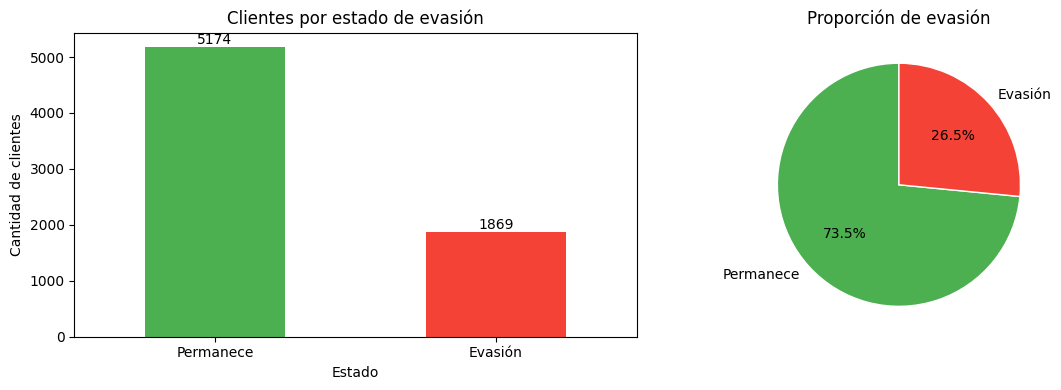

In [36]:
# Distribución de evasión (Churn)

# Selección de dataset y columna objetivo
if "df_estandar" in globals() and "Evasion" in df_estandar.columns:
    serie_evasion = df_estandar["Evasion"].map({0: "Permanece", 1: "Evasión"})
elif "df_limpio" in globals() and "Churn" in df_limpio.columns:
    serie_evasion = df_limpio["Churn"].map({"No": "Permanece", "Yes": "Evasión"})
else:
    raise NameError("No se encontró una columna de evasión válida en los datasets actuales.")

# Conteos y proporciones
conteo = serie_evasion.value_counts().reindex(["Permanece", "Evasión"]).fillna(0).astype(int)
proporcion = (conteo / conteo.sum() * 100).round(2)

print("Distribución de evasión (conteo):")
display(conteo.to_frame("clientes"))

print("\nDistribución de evasión (porcentaje):")
display(proporcion.to_frame("%"))

# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
colors = ["#4CAF50", "#F44336"]
conteo.plot(kind="bar", ax=axes[0], color=colors, rot=0)
axes[0].set_title("Clientes por estado de evasión")
axes[0].set_xlabel("Estado")
axes[0].set_ylabel("Cantidad de clientes")
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + max(conteo.values) * 0.01, str(v), ha="center")

# Gráfico circular
axes[1].pie(
    conteo.values,
    labels=conteo.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white"}
    )
axes[1].set_title("Proporción de evasión")

plt.tight_layout()
plt.show()

## Evasión por variables categóricas
En este bloque se comparan recuentos y porcentajes de evasión según categorías de cliente y servicio para identificar segmentos de mayor riesgo.


--- customer.gender ---


Estado_Evasion,Permanece,Evasión
customer.gender,,
Female,2549,939
Male,2625,930


Estado_Evasion,% Permanece,% Evasión
customer.gender,,
Female,73.08,26.92
Male,73.84,26.16


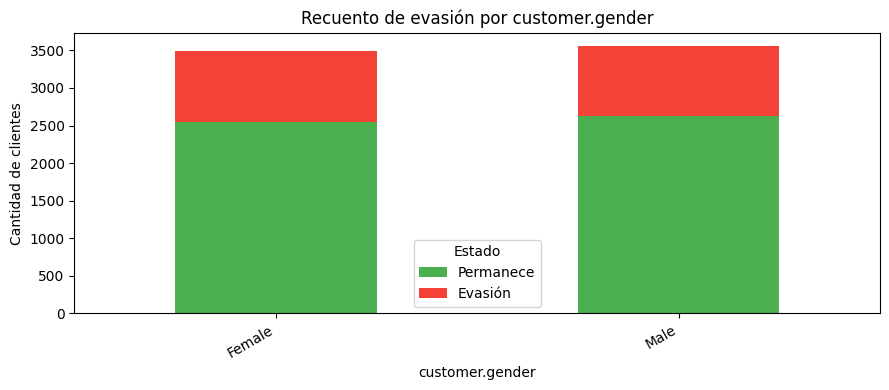


--- account.Contract ---


Estado_Evasion,Permanece,Evasión
account.Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


Estado_Evasion,% Permanece,% Evasión
account.Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


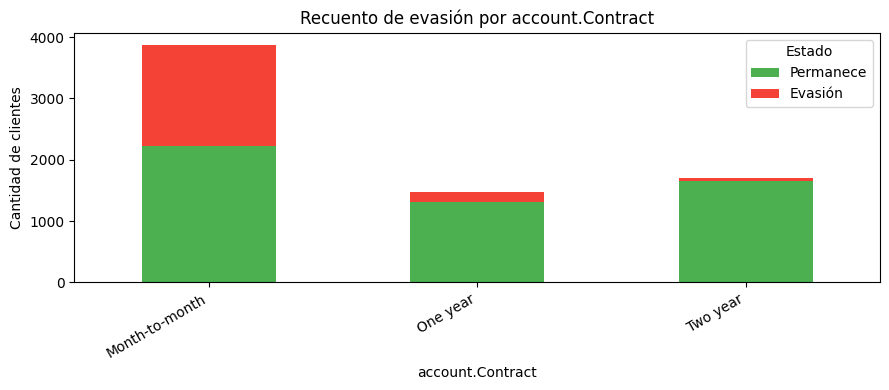


--- account.PaymentMethod ---


Estado_Evasion,Permanece,Evasión
account.PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


Estado_Evasion,% Permanece,% Evasión
account.PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


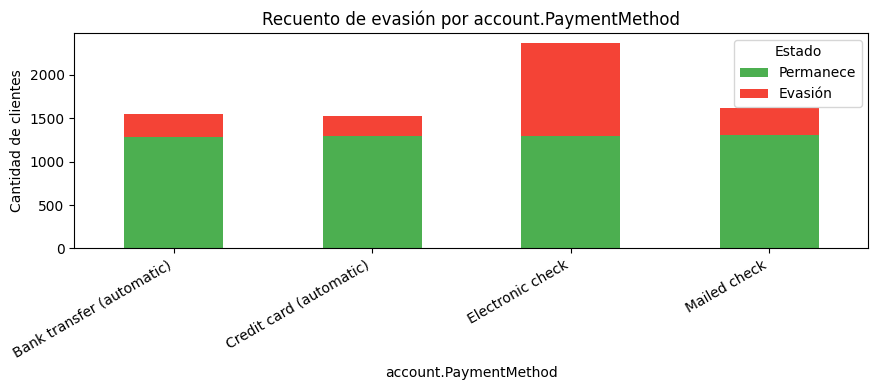


--- internet.InternetService ---


Estado_Evasion,Permanece,Evasión
internet.InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


Estado_Evasion,% Permanece,% Evasión
internet.InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


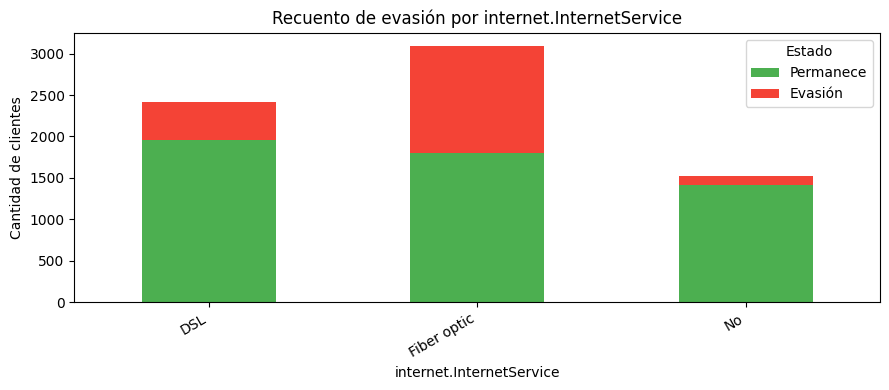


--- phone.MultipleLines ---


Estado_Evasion,Permanece,Evasión
phone.MultipleLines,,
No,2541,849
No phone service,512,170
Yes,2121,850


Estado_Evasion,% Permanece,% Evasión
phone.MultipleLines,,
No,74.96,25.04
No phone service,75.07,24.93
Yes,71.39,28.61


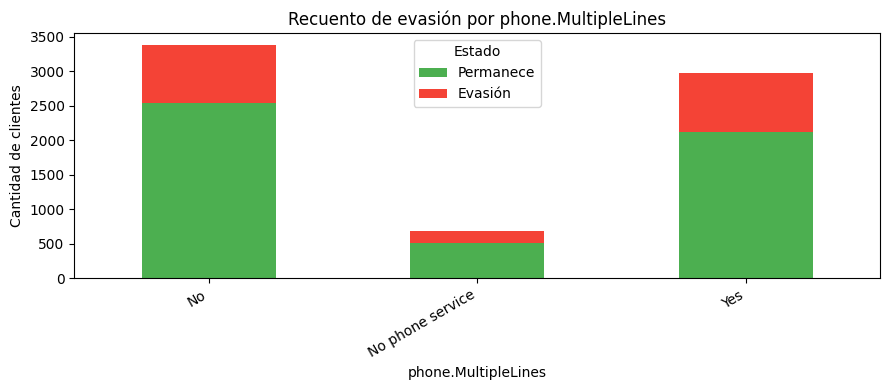


--- customer.Partner ---


Estado_Evasion,Permanece,Evasión
customer.Partner,,
No,2441,1200
Yes,2733,669


Estado_Evasion,% Permanece,% Evasión
customer.Partner,,
No,67.04,32.96
Yes,80.34,19.66


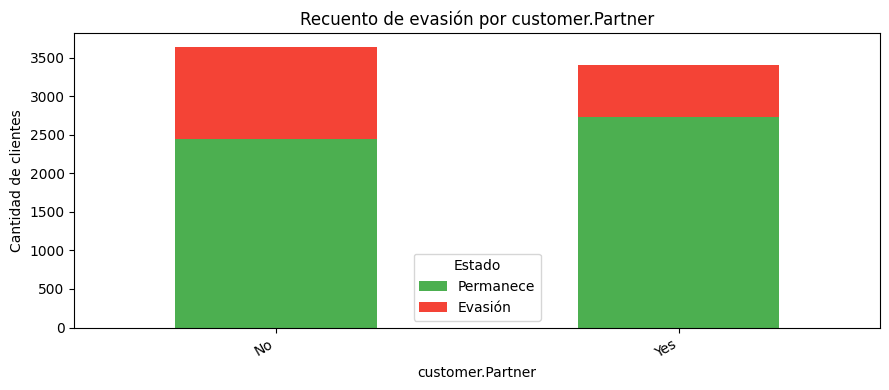


--- customer.Dependents ---


Estado_Evasion,Permanece,Evasión
customer.Dependents,,
No,3390,1543
Yes,1784,326


Estado_Evasion,% Permanece,% Evasión
customer.Dependents,,
No,68.72,31.28
Yes,84.55,15.45


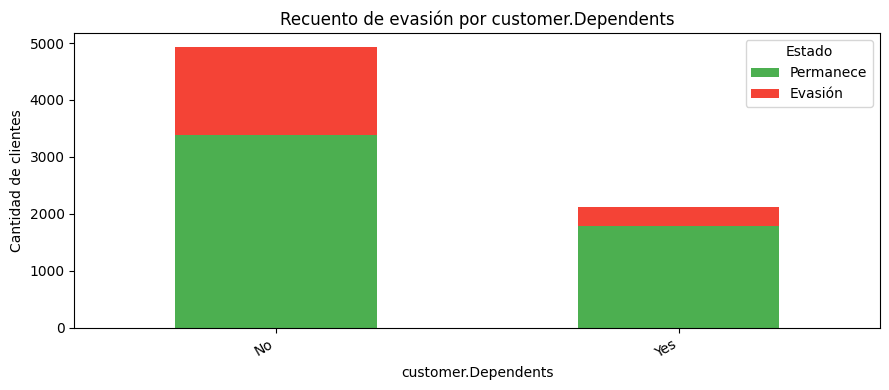

In [37]:
# Recuento de evasión por variables categóricas
if "df_limpio" not in globals():
    raise NameError("No existe df_limpio. Ejecuta primero las celdas de limpieza.")

# Base para análisis categórico con etiquetas legibles
df_cat = agregar_estado_evasion(df_limpio, churn_col="Churn")

variables_categoricas = [
    "customer.gender",
    "account.Contract",
    "account.PaymentMethod",
    "internet.InternetService",
    "phone.MultipleLines",
    "customer.Partner",
    "customer.Dependents"
]
variables_categoricas = [v for v in variables_categoricas if v in df_cat.columns]

for var in variables_categoricas:
    print(f"\n--- {var} ---")

    # Recuento absoluto por categoría y estado de evasión
    tabla_recuento = pd.crosstab(df_cat[var], df_cat["Estado_Evasion"])
    tabla_recuento = ordenar_columnas_estado(tabla_recuento)
    display(tabla_recuento)

    # Tasa de evasión por categoría
    tabla_pct = pd.crosstab(df_cat[var], df_cat["Estado_Evasion"], normalize="index") * 100
    tabla_pct = ordenar_columnas_estado(tabla_pct).round(2)
    tabla_pct = tabla_pct.rename(columns={"Permanece": "% Permanece", "Evasión": "% Evasión"})
    display(tabla_pct)

    # Gráfico de recuento apilado
    ax = tabla_recuento.plot(
        kind="bar",
        stacked=True,
        figsize=(9, 4),
        color=["#4CAF50", "#F44336"]
    )
    ax.set_title(f"Recuento de evasión por {var}")
    ax.set_xlabel(var)
    ax.set_ylabel("Cantidad de clientes")
    ax.legend(title="Estado")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## Evasión por variables numéricas
Aquí se analiza cómo cambian tenure y cargos entre clientes que permanecen y clientes que cancelan, usando tablas por rangos y distribuciones comparativas.


=== customer.tenure ===
Resumen por estado de evasión:


,count,mean,median,std
Estado_Evasion,,,,
Evasión,1869,17.98,10.0,19.53
Permanece,5174,37.57,38.0,24.11


Conteo por rangos (5 bins):


Estado_Evasion,Permanece,Evasión
customer.tenure,,
"(-0.073, 14.4]",1272,1099
"(14.4, 28.8]",831,295
"(28.8, 43.2]",774,215
"(43.2, 57.6]",805,142
"(57.6, 72.0]",1492,118


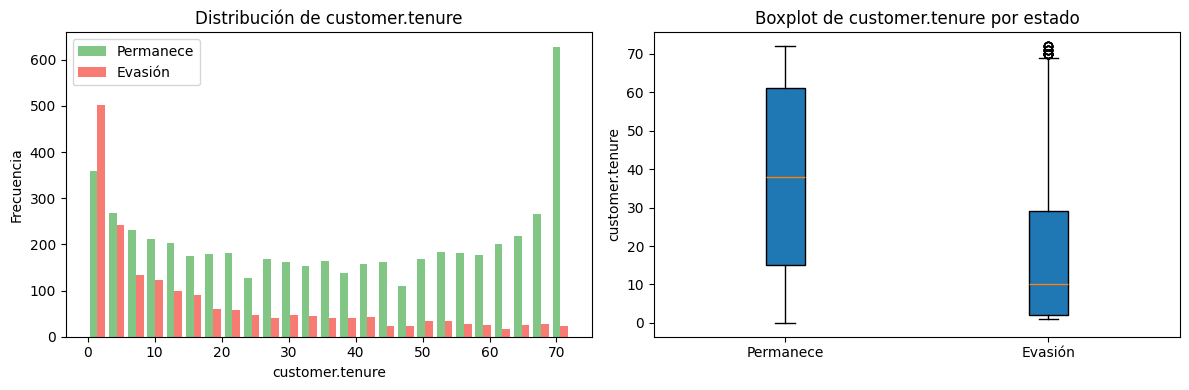


=== account.Charges.Monthly ===
Resumen por estado de evasión:


,count,mean,median,std
Estado_Evasion,,,,
Evasión,1869,74.44,79.65,24.67
Permanece,5174,61.27,64.43,31.09


Conteo por rangos (5 bins):


Estado_Evasion,Permanece,Evasión
account.Charges.Monthly,,
"(18.148999999999997, 38.35]",1592,205
"(38.35, 58.45]",734,271
"(58.45, 78.55]",964,403
"(78.55, 98.65]",1151,675
"(98.65, 118.75]",733,315


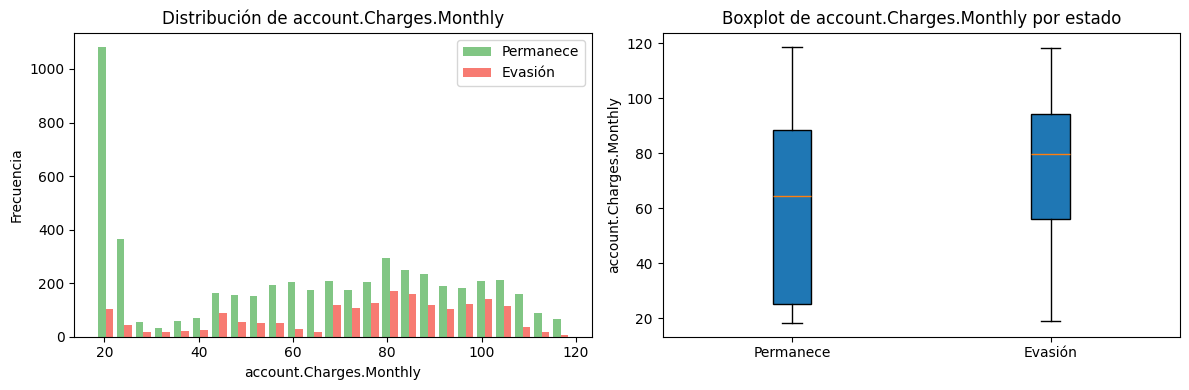


=== account.Charges.Total ===
Resumen por estado de evasión:


,count,mean,median,std
Estado_Evasion,,,,
Evasión,1869,1531.8,703.55,1890.82
Permanece,5174,2549.91,1679.52,2329.95


Conteo por rangos (5 bins):


Estado_Evasion,Permanece,Evasión
account.Charges.Total,,
"(-8.686, 1736.96]",2638,1290
"(1736.96, 3473.92]",896,292
"(3473.92, 5210.88]",728,146
"(5210.88, 6947.84]",603,104
"(6947.84, 8684.8]",309,37


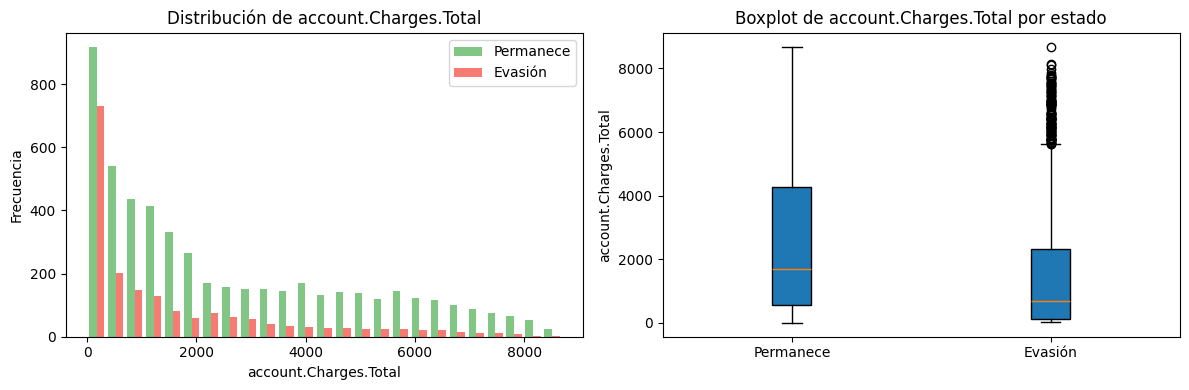


=== Cuentas_Diarias ===
Resumen por estado de evasión:


,count,mean,median,std
Estado_Evasion,,,,
Evasión,1869,2.48,2.66,0.82
Permanece,5174,2.04,2.15,1.04


Conteo por rangos (5 bins):


Estado_Evasion,Permanece,Evasión
Cuentas_Diarias,,
"(0.606, 1.28]",1596,205
"(1.28, 1.95]",737,274
"(1.95, 2.62]",968,403
"(2.62, 3.29]",1147,680
"(3.29, 3.96]",726,307


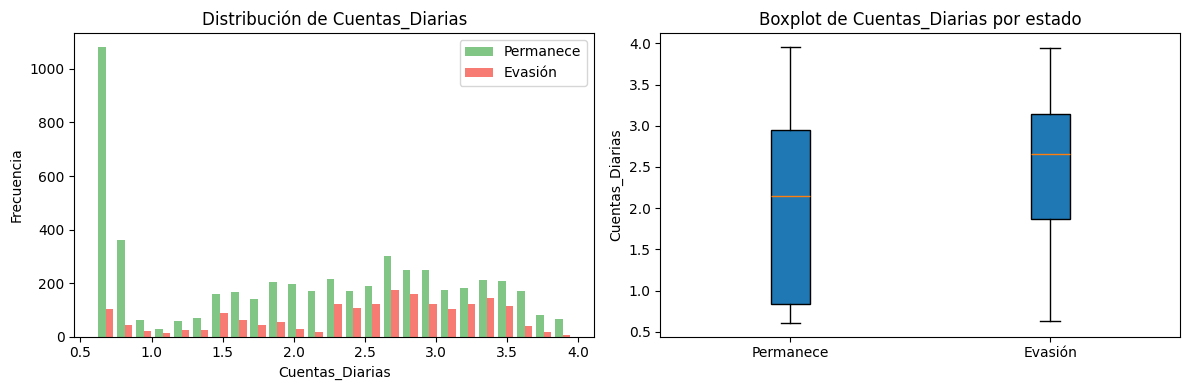

In [38]:
# Conteo de evasión por variables numéricas
if "df_limpio" not in globals():
    raise NameError("No existe df_limpio. Ejecuta primero las celdas de limpieza.")

df_num = agregar_estado_evasion(df_limpio, churn_col="Churn")

variables_numericas = [
    "customer.tenure",
    "account.Charges.Monthly",
    "account.Charges.Total",
    "Cuentas_Diarias"
]
variables_numericas = [v for v in variables_numericas if v in df_num.columns]

for var in variables_numericas:
    print(f"\n=== {var} ===")
    serie_num = pd.to_numeric(df_num[var], errors="coerce")

    # 1) Resumen descriptivo por estado de evasión
    resumen = (
        df_num.assign(_num=serie_num)
        .groupby("Estado_Evasion")["_num"]
        .agg(["count", "mean", "median", "std"])
        .round(2)
    )
    print("Resumen por estado de evasión:")
    display(resumen)

    # 2) Conteo por rangos (bins)
    bins = 5
    rango = pd.cut(serie_num, bins=bins, include_lowest=True)
    tabla_bins = pd.crosstab(rango, df_num["Estado_Evasion"])
    tabla_bins = ordenar_columnas_estado(tabla_bins)
    print(f"Conteo por rangos ({bins} bins):")
    display(tabla_bins)

    # 3) Visualizaciones comparativas
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histograma superpuesto
    axes[0].hist(
        [
            serie_num[df_num["Estado_Evasion"] == "Permanece"].dropna(),
            serie_num[df_num["Estado_Evasion"] == "Evasión"].dropna()
        ],
        bins=25,
        label=["Permanece", "Evasión"],
        color=["#4CAF50", "#F44336"],
        alpha=0.7
    )
    axes[0].set_title(f"Distribución de {var}")
    axes[0].set_xlabel(var)
    axes[0].set_ylabel("Frecuencia")
    axes[0].legend()

    # Boxplot por estado
    data_permanece = serie_num[df_num["Estado_Evasion"] == "Permanece"].dropna()
    data_evasion = serie_num[df_num["Estado_Evasion"] == "Evasión"].dropna()
    axes[1].boxplot([data_permanece, data_evasion], tick_labels=["Permanece", "Evasión"], patch_artist=True)
    axes[1].set_title(f"Boxplot de {var} por estado")
    axes[1].set_ylabel(var)

    plt.tight_layout()
    plt.show()

# 📄 Informe final

## 1) Introducción
El objetivo de este análisis fue estudiar la **evasión de clientes (Churn)** en Telecom X LATAM para identificar patrones de comportamiento asociados a la cancelación del servicio y generar recomendaciones accionables para reducirla.

El problema de churn impacta directamente en ingresos y costos de adquisición, por lo que entender **qué perfiles cancelan más** permite priorizar acciones de retención más efectivas.

## 2) Limpieza y tratamiento de datos
Durante la preparación de datos se realizaron los siguientes pasos:
- Carga del archivo JSON y validación de estructura general.
- Aplanamiento de estructuras anidadas para facilitar el análisis por variables.
- Detección de inconsistencias: valores vacíos, duplicados, formatos numéricos y categorías.
- Estandarización de textos (trim, normalización de categorías) y depuración de la variable objetivo `Churn`.
- Conversión de campos numéricos clave (`account.Charges.Total`, `customer.tenure`, `account.Charges.Monthly`).
- Creación de la variable derivada **`Cuentas_Diarias`** (`Cargo_Mensual / 30`) para mayor granularidad de análisis.
- Transformación opcional a dataset estandarizado (`df_estandar`) con variables binarias/renombradas.

Resultado del tratamiento: dataset limpio de **7043 registros** y variables críticas sin nulos para análisis de evasión.

## 3) Análisis exploratorio de datos (EDA)
Se desarrollaron análisis descriptivos y visuales para comprender la distribución de churn:
- **Distribución general de evasión**: 73.46% permanece vs 26.54% evasión.
- **Variables categóricas**: análisis de recuento y tasa de evasión por género, tipo de contrato, método de pago, servicio de internet, dependientes y pareja.
- **Variables numéricas**: comparación por estado de evasión con histogramas, boxplots y conteo por rangos para tenure y cargos.

Los gráficos del notebook evidencian diferencias claras entre clientes con alta y baja probabilidad de evasión.

## 4) Conclusiones e insights
Hallazgos principales:
1. **Tipo de contrato** es un factor crítico: clientes `Month-to-month` presentan mucha mayor evasión que contratos de 1 y 2 años.
2. **Método de pago** influye fuertemente: `Electronic check` concentra la tasa de evasión más alta.
3. **Servicio de internet**: clientes con `Fiber optic` muestran mayor proporción de cancelación que DSL o clientes sin internet.
4. **Antigüedad (tenure)**: clientes que cancelan tienen, en promedio, menor tiempo de permanencia.
5. **Gasto mensual / diario**: el grupo con evasión exhibe cargos mensuales y diarios más altos.
6. **Perfil familiar**: clientes sin pareja y sin dependientes tienden a mostrar mayor evasión.

En síntesis, la evasión se asocia principalmente con **contratos de baja permanencia, mayor carga de pago recurrente y ciertos segmentos de servicio/método de pago**.

## 5) Recomendaciones
A partir de los hallazgos, se proponen las siguientes acciones estratégicas:
- Diseñar campañas de migración de `Month-to-month` hacia planes anuales con incentivos (descuentos, beneficios por permanencia).
- Implementar acciones de retención temprana para clientes de baja antigüedad (primeros meses de contrato).
- Revisar propuesta de valor para clientes con `Fiber optic` y/o cargos elevados (paquetes, beneficios, soporte prioritario).
- Crear tácticas específicas para usuarios con `Electronic check`, promoviendo métodos automáticos con beneficios.
- Desarrollar modelos de propensión de churn usando las variables identificadas como más influyentes para activar alertas preventivas.
- Medir impacto con experimentos controlados (A/B tests) y seguimiento mensual de tasa de evasión por segmento.

## Cierre
El análisis permitió identificar segmentos prioritarios y palancas de acción concretas para reducir la evasión. La combinación de limpieza, estandarización y análisis exploratorio deja una base sólida para pasar a una etapa predictiva y de optimización de estrategias de retención.

In [39]:
# Soporte cuantitativo del informe final
if "df_limpio" not in globals():
    raise NameError("No existe df_limpio. Ejecuta primero las celdas previas.")

df_rep = agregar_estado_evasion(df_limpio, churn_col="Churn")

# KPI general
kpi = pd.DataFrame({
    "Metricas": ["Total clientes", "Clientes con evasión", "% evasión"],
    "Valor": [
        len(df_rep),
        (df_rep["Estado_Evasion"] == "Evasión").sum(),
        round((df_rep["Estado_Evasion"] == "Evasión").mean() * 100, 2)
    ]
})
print("KPIs generales:")
display(kpi)

# Top riesgos categóricos por tasa de evasión
def tasa_evasion_por_categoria(dataframe, columna):
    tabla = pd.crosstab(dataframe[columna], dataframe["Estado_Evasion"], normalize="index") * 100
    tabla = ordenar_columnas_estado(tabla).round(2)
    tabla = tabla.rename(columns={"Permanece": "% Permanece", "Evasión": "% Evasión"})
    return tabla.sort_values("% Evasión", ascending=False)

columnas_segmento = [
    "account.Contract",
    "account.PaymentMethod",
    "internet.InternetService",
    "customer.Partner",
    "customer.Dependents"
]
columnas_segmento = [c for c in columnas_segmento if c in df_rep.columns]

for col in columnas_segmento:
    print(f"\nTop categorías por evasión: {col}")
    display(tasa_evasion_por_categoria(df_rep, col).head(5))

# Comparativo numérico principal
columnas_num_base = ["customer.tenure", "account.Charges.Monthly", "account.Charges.Total"]
if "Cuentas_Diarias" in df_rep.columns:
    columnas_num_base.append("Cuentas_Diarias")

resumen_numerico = (
    df_rep.groupby("Estado_Evasion")[columnas_num_base]
    .agg(["mean", "median"])
    .round(2)
)
print("\nComparativo numérico (media y mediana):")
display(resumen_numerico)

KPIs generales:


,Metricas,Valor
0,Total clientes,7043.00
1,Clientes con evasión,1869.00
2,% evasión,26.54



Top categorías por evasión: account.Contract


Estado_Evasion,% Permanece,% Evasión
account.Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83



Top categorías por evasión: account.PaymentMethod


...

Estado_Evasion,% Permanece,% Evasión
customer.Partner,,
No,67.04,32.96
Yes,80.34,19.66



Top categorías por evasión: customer.Dependents


Estado_Evasion,% Permanece,% Evasión
customer.Dependents,,
No,68.72,31.28
Yes,84.55,15.45



Comparativo numérico (media y mediana):


customer.tenure        account.Charges.Monthly         \
                          mean median                    mean median   
Estado_Evasion                                                         
Evasión                  17.98   10.0                   74.44  79.65   
Permanece                37.57   38.0                   61.27  64.43   

               account.Charges.Total          Cuentas_Diarias         
                                mean   median            mean median  
Estado_Evasion                                                        
Evasión                       1531.8   703.55            2.48   2.66  
Permanece                    2549.91  1679.52            2.04   2.15